# 04 - Regional Sales Segmentation using K-Means Clustering

Fokus dari *notebook* ini adalah **Unsupervised Learning**. Kita akan menggunakan algoritma **K-Means Clustering** untuk mengelompokkan kota-kota berdasarkan performa finansialnya (Sales dan Profit). 

Segmentasi ini akan sangat membantu tim bisnis e-commerce untuk memvisualisasikan wilayah mana yang masuk kategori "Emas", "Berisiko", atau "Berkembang", sehingga alokasi strategi marketing dan logistik menjadi lebih tepat sasaran.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import joblib

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')

# 1. Load Data
df = pd.read_csv('../Data/Processed/ecommerce_clean.csv')

# Standarisasi nama kolom
df.columns = [col.strip().capitalize() for col in df.columns]

print(f"Total data transaksi: {len(df)}")

Total data transaksi: 5000


In [3]:
# 2. Agregasi Data per Kota
# Kita hitung Total Sales, Total Profit, dan Profit Margin rata-rata per Kota
city_stats = df.groupby(['Region', 'City']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit', lambda x: (x.sum() / df.loc[x.index, 'Sales'].sum()) * 100)
).reset_index()

display(city_stats.head())

,Region,City,Total_Sales,Total_Profit,Avg_Margin
0,East,Bhubaneswar,27088786.45,4070957.02,15.028200
1,East,Guwahati,29606888.90,4487271.28,15.156173
2,East,Kolkata,24464634.15,3729700.69,15.245275
3,East,Patna,27702815.20,4131315.44,14.912981
4,East,Ranchi,26948513.25,4113313.69,15.263602


In [4]:
# 3. Scaling Fitur Numerik
features_to_cluster = ['Total_Sales', 'Total_Profit', 'Avg_Margin']
X = city_stats[features_to_cluster]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data berhasil di-scaling dan siap untuk K-Means!")

Data berhasil di-scaling dan siap untuk K-Means!


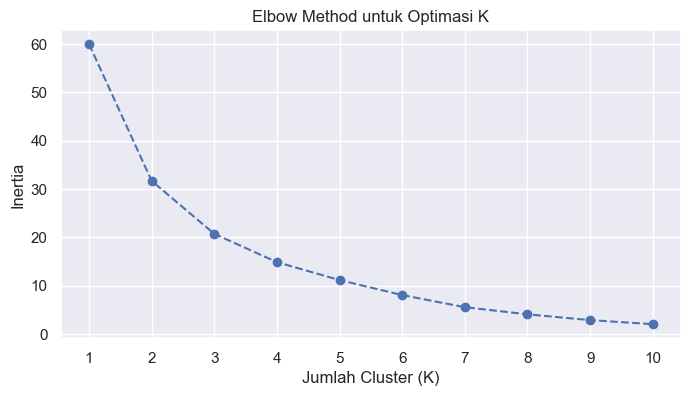

In [5]:
# 4. Elbow Method untuk mencari nilai K terbaik
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method untuk Optimasi K')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.show()

# Dari grafik biasanya terlihat patahan (elbow) di angka 3 atau 4.
# Kita asumsikan K=3 untuk ("Tinggi", "Sedang", "Rendah")

In [6]:
# 5. Latih K-Means dengan K=3
OPTIMAL_K = 3
kmeans_model = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
city_stats['Cluster'] = kmeans_model.fit_predict(X_scaled)

# Mari kita lihat rata-rata statistik untuk setiap Cluster untuk memberi nama/label
cluster_summary = city_stats.groupby('Cluster')[features_to_cluster].mean().round(2)
display(cluster_summary)

# Opsional: Memberi label deskriptif pada cluster
def label_cluster(row):
    if row['Cluster'] == cluster_summary['Total_Profit'].idxmax():
        return "Tier 1 - High Profit & Sales"
    elif row['Cluster'] == cluster_summary['Total_Profit'].idxmin():
        return "Tier 3 - Low Performers"
    else:
        return "Tier 2 - Average Growth"

city_stats['Cluster_Label'] = city_stats.apply(label_cluster, axis=1)
print(city_stats['Cluster_Label'].value_counts())

,Total_Sales,Total_Profit,Avg_Margin
Cluster,,,
0,25172296.39,3838721.12,15.25
1,28714687.36,4288412.32,14.93
2,24304994.19,3578287.88,14.73


Cluster_Label
Tier 1 - High Profit & Sales    10
Tier 3 - Low Performers          6
Tier 2 - Average Growth          4
Name: count, dtype: int64


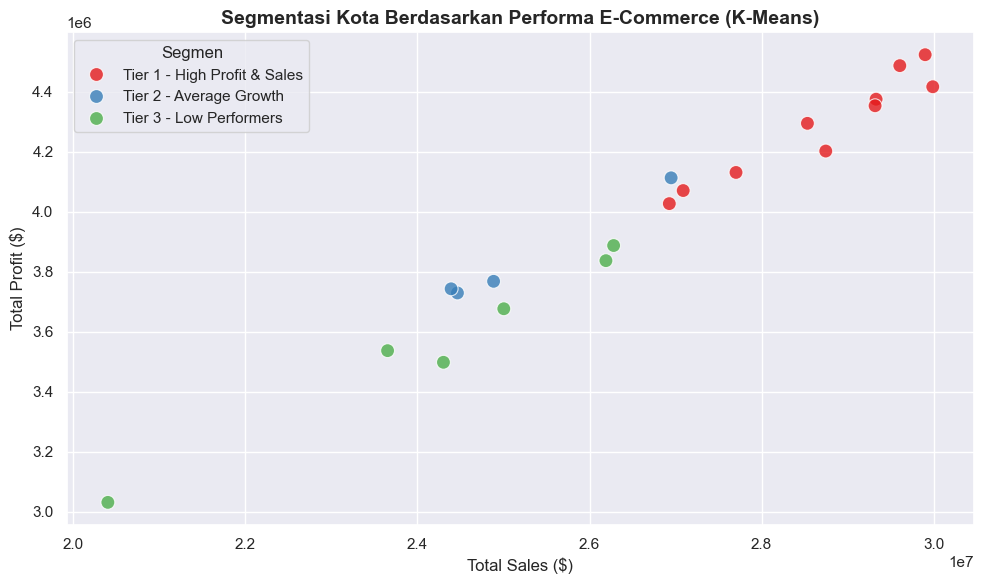

In [7]:
# 6. Scatter Plot Hasil Clustering
plt.figure(figsize=(10, 6))

# Kita plot Total Sales vs Total Profit
sns.scatterplot(
    data=city_stats, 
    x='Total_Sales', 
    y='Total_Profit', 
    hue='Cluster_Label', 
    palette='Set1', 
    s=100, 
    alpha=0.8
)

plt.title('Segmentasi Kota Berdasarkan Performa E-Commerce (K-Means)', fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Total Profit ($)')
plt.legend(title='Segmen')
plt.tight_layout()
plt.show()

In [ ]:
# 7. Simpan Model Scaler, K-Means, dan Data Hasil Clustering
# Data ini nanti bisa dipanggil di Streamlit (app.py) untuk ditampilkan ke dalam Peta Pydeck/Plotly
joblib.dump(scaler, 'scaler_kmeans.pkl')
joblib.dump(kmeans_model, 'model_kmeans_region.pkl')
city_stats.to_csv('../Data/Processed/city_clusters.csv', index=False)

print("Model K-Means, Scaler, dan Data Cluster Kota berhasil disimpan!")